In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge,Lasso,LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import re

# Data loading and initial assessment

In [2]:
df = pd.read_csv("used_cars.csv")
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.shape

(4009, 12)

In [4]:
df.dtypes

brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object

In [5]:
df.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [6]:
col = df.columns
col

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

In [7]:
df.info(memory_usage=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
brand           4009 non-null object
model           4009 non-null object
model_year      4009 non-null int64
milage          4009 non-null object
fuel_type       3839 non-null object
engine          4009 non-null object
transmission    4009 non-null object
ext_col         4009 non-null object
int_col         4009 non-null object
accident        3896 non-null object
clean_title     3413 non-null object
price           4009 non-null object
dtypes: int64(1), object(11)

In [8]:
df.duplicated().sum()

0

# Data cleaning

In [9]:
for c in col:
    print(f"{c}: {df[c].nunique()} : {df[c].dtypes} : {df[c].isna().sum()}")

brand: 57 : object : 0
model: 1898 : object : 0
model_year: 34 : int64 : 0
milage: 2818 : object : 0
fuel_type: 7 : object : 170
engine: 1146 : object : 0
transmission: 62 : object : 0
ext_col: 319 : object : 0
int_col: 156 : object : 0
accident: 2 : object : 113
clean_title: 1 : object : 596
price: 1569 : object : 0


In [10]:
df[['brand','model']].head(10)

,brand,model
0,Ford,Utility Police Interceptor Base
1,Hyundai,Palisade SEL
2,Lexus,RX 350 RX 350
3,INFINITI,Q50 Hybrid Sport
4,Audi,Q3 45 S line Premium Plus
5,Acura,ILX 2.4L
6,Audi,S3 2.0T Premium Plus
7,BMW,740 iL
8,Lexus,RC 350 F Sport
9,Tesla,Model X Long Range Plus


In [11]:
df['brand'].value_counts().head(20)

Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Tesla             87
Kia               76
Hyundai           72
Acura             64
Subaru            64
Name: brand, dtype: int64

In [12]:
df['model'].value_counts().head(20)

M3 Base                 30
F-150 XLT               24
Corvette Base           22
1500 Laramie            18
Camaro 2SS              17
Model Y Long Range      17
Wrangler Sport          17
911 Carrera             16
Mustang GT Premium      16
M4 Base                 15
911 Carrera S           14
F-250 Lariat            14
Explorer XLT            14
F-150 Lariat            13
E-Class E 350           13
M5 Base                 13
E-Class E 350 4MATIC    13
Land Cruiser Base       12
Macan S                 12
ES 350 Base             12
Name: model, dtype: int64

In [13]:
df = df.drop(columns=['model'])

In [14]:
df.shape

(4009, 11)

In [15]:
df['milage'].head(10)

0     51,000 mi.
1     34,742 mi.
2     22,372 mi.
3     88,900 mi.
4      9,835 mi.
5    136,397 mi.
6     84,000 mi.
7    242,000 mi.
8     23,436 mi.
9     34,000 mi.
Name: milage, dtype: object

In [16]:
df['milage'].isna().sum()

0

In [17]:
df['milage'].sample(10)

2071     58,816 mi.
645     121,800 mi.
924       1,750 mi.
3784     35,566 mi.
2447    170,443 mi.
1689     17,451 mi.
2839     14,381 mi.
1655     32,957 mi.
2044     51,338 mi.
52      110,900 mi.
Name: milage, dtype: object

In [18]:
df['milage'] = df['milage'].astype(str)
df['milage'] = df['milage'].str.replace(",","",regex=False)
df['milage'] = df['milage'].str.replace("mi","",regex=False)
df['milage'] = df['milage'].str.replace(".","",regex=False)
df['milage'] = df['milage'].astype(float)
df['milage'].dtypes

dtype('float64')

In [19]:
df['fuel_type'].dtypes

dtype('O')

In [20]:
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', nan, 'Diesel',
       'Plug-In Hybrid', '–', 'not supported'], dtype=object)

In [21]:
df['fuel_type'] = df['fuel_type'].replace(["–","not supported"],"unknown")
df['fuel_type'] = df['fuel_type'].fillna("unknown")
df['fuel_type'].unique()

array(['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'unknown', 'Diesel',
       'Plug-In Hybrid'], dtype=object)

In [22]:
df['fuel_type'].isna().sum()

0

In [23]:
df = df.drop(columns = ['int_col','ext_col','clean_title'])

In [24]:
df['accident'].nunique()

2

In [25]:
df['accident'] = df['accident'].replace({'At least 1 accident or damage reported':'yes',
                                        'None reported':'no'})
df['accident'] = df['accident'].fillna('unknown')
df['accident'].unique()

array(['yes', 'no', 'unknown'], dtype=object)

In [26]:
df['price'].nunique()

1569

In [27]:
df['price'].isna().sum()

0

In [28]:
df['price'] = df['price'].astype(str)
df['price'] = df['price'].str.replace("$","",regex=False)
df['price'] = df['price'].str.replace(",","",regex=False)
df['price'] = df['price'].astype(float)
df['price'].unique()
df['price'].dtypes

dtype('float64')

# feature engineering

In [29]:
df['transmission'].nunique()

62

In [30]:
df['transmission'].head(5)

0          6-Speed A/T
1    8-Speed Automatic
2            Automatic
3          7-Speed A/T
4    8-Speed Automatic
Name: transmission, dtype: object

In [31]:
df['transmission'].sample(5)

204     Transmission w/Dual Shift Mode
1776                       6-Speed A/T
1638                       8-Speed A/T
2165                       5-Speed A/T
2464                       5-Speed A/T
Name: transmission, dtype: object

In [32]:
def simplify_transmission(x):
    x = str(x).lower()
    if 'a/t' in x or 'automatic' in x:
        return 'Automatic'
    elif 'm/t' in x or 'manual' in x:
        return 'Manual'
    elif 'cvt' in x:
        return 'CVT'
    elif 'dual' in x:
        return 'Dual_Shift'
    else:
        return 'Unknown'

In [33]:
df['transmission'] = df['transmission'].apply(simplify_transmission)
df['transmission'].value_counts()

Automatic     3148
Dual_Shift     398
Manual         372
CVT             63
Unknown         28
Name: transmission, dtype: int64

In [34]:
df.columns

Index(['brand', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission',
       'accident', 'price'],
      dtype='object')

In [35]:
def HP_extractor(x):
    x = str(x)
    match = re.search(r'(\d+\.?\d*)HP',x)
    if match:
        return float(match.group(1))
    else:
        return np.nan

In [36]:
def engine_size_extractor(x):
    x = str(x)
    match = re.search(r'(\d+\.?\d*)L',x)
    if match:
        return float(match.group(1))
    else:
        return np.nan

In [37]:
def cylinder_extractor(x):
    x = str(x)
    match = re.search(r'V(\d+)|I(\d+)|(\d+)\sCylinder|Straight\s(\d+)',x)
    if match:
        for group in match.groups():
            if group:
                return int(group)
    
    return np.nan

In [38]:
def has_turbo(x):
    x = str(x).lower()
    if 'turbo' in x:
        return 1
    else:
        return 0

In [39]:
def is_electric(x):
    x = str(x).lower()
    if 'electric' in x:
        return 1
    else:
        return 0

In [40]:
df.columns

Index(['brand', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission',
       'accident', 'price'],
      dtype='object')

In [41]:
df['HP'] = df['engine'].apply(HP_extractor)
df['engine_size'] = df['engine'].apply(engine_size_extractor)
df['cylinder'] = df['engine'].apply(cylinder_extractor)
df['turbo'] = df['engine'].apply(has_turbo)
df['electric'] = df['engine'].apply(is_electric)


In [42]:
df = df.drop(columns=['engine'])

In [43]:
df.head()

,brand,model_year,milage,fuel_type,transmission,accident,price,HP,engine_size,cylinder,turbo,electric
0,Ford,2013,51000.0,E85 Flex Fuel,Automatic,yes,10300.0,300.0,3.7,6.0,0,0
1,Hyundai,2021,34742.0,Gasoline,Automatic,yes,38005.0,NaN,3.8,6.0,0,0
2,Lexus,2022,22372.0,Gasoline,Automatic,no,54598.0,NaN,NaN,NaN,0,0
3,INFINITI,2015,88900.0,Hybrid,Automatic,no,15500.0,354.0,3.5,6.0,0,1
4,Audi,2021,9835.0,Gasoline,Automatic,no,34999.0,NaN,2.0,4.0,1,0


In [44]:
df.isna().sum().tail()

HP             808
engine_size    377
cylinder       440
turbo            0
electric         0
dtype: int64

In [45]:
df['HP'] = df['HP'].fillna(df['HP'].median())
df['engine_size'] = df['engine_size'].fillna(df['engine_size'].median())
df['cylinder'] = df['cylinder'].fillna(df['cylinder'].median())

df.isna().sum()

brand           0
model_year      0
milage          0
fuel_type       0
transmission    0
accident        0
price           0
HP              0
engine_size     0
cylinder        0
turbo           0
electric        0
dtype: int64

In [46]:
df['age'] = 2026-df['model_year']
df = df.drop(columns=['model_year'])
df.columns

Index(['brand', 'milage', 'fuel_type', 'transmission', 'accident', 'price',
       'HP', 'engine_size', 'cylinder', 'turbo', 'electric', 'age'],
      dtype='object')

# Exploratory data analysis

In [47]:
numeric = df._get_numeric_data()
numeric.head()

,milage,price,HP,engine_size,cylinder,turbo,electric,age
0,51000.0,10300.0,300.0,3.7,6.0,0,0,13
1,34742.0,38005.0,310.0,3.8,6.0,0,0,5
2,22372.0,54598.0,310.0,3.5,6.0,0,0,4
3,88900.0,15500.0,354.0,3.5,6.0,0,1,11
4,9835.0,34999.0,310.0,2.0,4.0,1,0,5


In [48]:
num_col = numeric.columns
for x in num_col:
    print(f"{x}: {numeric[x].skew()}")

milage: 1.1599748853042458
price: 19.513551204216057
HP: 1.1704809879688711
engine_size: 0.5516003498978629
cylinder: 0.4103392272850828
turbo: 3.2398261954638357
electric: 2.941861125925147
age: 1.0892312577318568


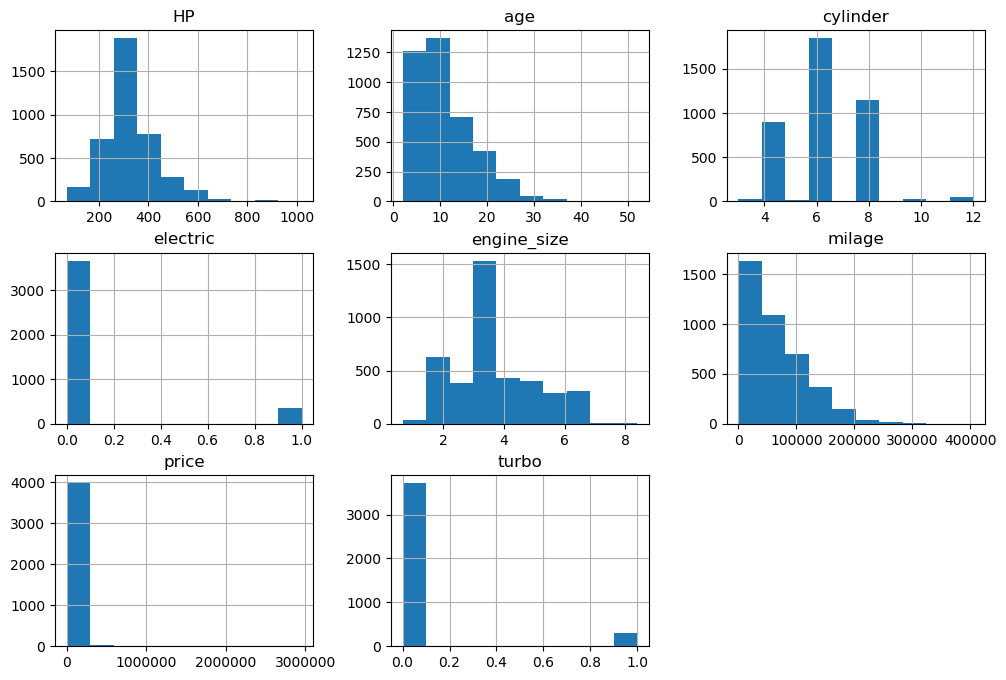

In [49]:
numeric.hist(figsize=(12,8))
plt.show()

In [50]:
numeric.corr()['price']

milage        -0.305528
price          1.000000
HP             0.267426
engine_size    0.173865
cylinder       0.220949
turbo          0.139124
electric       0.028009
age           -0.199496
Name: price, dtype: float64

In [56]:
numeric.describe(include='all')

,milage,price,HP,engine_size,cylinder,turbo,electric,age
count,4009.000000,4.009000e+03,4009.000000,4009.000000,4009.000000,4009.000000,4009.000000,4009.000000
mean,64717.551010,4.455319e+04,327.730856,3.689386,6.195061,0.074582,0.086555,10.484410
std,52296.599459,7.871064e+04,109.604837,1.355937,1.611110,0.262749,0.281217,6.104816
min,100.000000,2.000000e+03,70.000000,0.650000,3.000000,0.000000,0.000000,2.000000
25%,23044.000000,1.720000e+04,268.000000,2.700000,6.000000,0.000000,0.000000,6.000000
50%,52775.000000,3.100000e+04,310.000000,3.500000,6.000000,0.000000,0.000000,9.000000
75%,94100.000000,4.999000e+04,381.000000,4.600000,8.000000,0.000000,0.000000,14.000000
max,405000.000000,2.954083e+06,1020.000000,8.400000,12.000000,1.000000,1.000000,52.000000


In [57]:
character = df.drop(columns=numeric.columns)
character.head(2)

,brand,fuel_type,transmission,accident
0,Ford,E85 Flex Fuel,Automatic,yes
1,Hyundai,Gasoline,Automatic,yes


In [58]:
cl_data = pd.concat([numeric,character],axis=1)
cl_data.head()

,milage,price,HP,engine_size,cylinder,turbo,electric,age,brand,fuel_type,transmission,accident
0,51000.0,10300.0,300.0,3.7,6.0,0,0,13,Ford,E85 Flex Fuel,Automatic,yes
1,34742.0,38005.0,310.0,3.8,6.0,0,0,5,Hyundai,Gasoline,Automatic,yes
2,22372.0,54598.0,310.0,3.5,6.0,0,0,4,Lexus,Gasoline,Automatic,no
3,88900.0,15500.0,354.0,3.5,6.0,0,1,11,INFINITI,Hybrid,Automatic,no
4,9835.0,34999.0,310.0,2.0,4.0,1,0,5,Audi,Gasoline,Automatic,no


In [59]:
cl_data.describe(include='all')

,milage,price,HP,engine_size,cylinder,turbo,electric,age,brand,fuel_type,transmission,accident
count,4009.000000,4.009000e+03,4009.000000,4009.000000,4009.000000,4009.000000,4009.000000,4009.000000,4009,4009,4009,4009
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57,6,5,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ford,Gasoline,Automatic,no
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,386,3309,3148,2910
mean,64717.551010,4.455319e+04,327.730856,3.689386,6.195061,0.074582,0.086555,10.484410,NaN,NaN,NaN,NaN
std,52296.599459,7.871064e+04,109.604837,1.355937,1.611110,0.262749,0.281217,6.104816,NaN,NaN,NaN,NaN
min,100.000000,2.000000e+03,70.000000,0.650000,3.000000,0.000000,0.000000,2.000000,NaN,NaN,NaN,NaN
25%,23044.000000,1.720000e+04,268.000000,2.700000,6.000000,0.000000,0.000000,6.000000,NaN,NaN,NaN,NaN
50%,52775.000000,3.100000e+04,310.000000,3.500000,6.000000,0.000000,0.000000,9.000000,NaN,NaN,NaN,NaN
75%,94100.000000,4.999000e+04,381.000000,4.600000,8.000000,0.000000,0.000000,14.000000,NaN,NaN,NaN,NaN


# preprocessing

In [60]:
x = df.drop(columns=['price'])
y = df['price']

In [61]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [63]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

In [64]:
cat_cols = ['brand','fuel_type','transmission','accident']
x_train = pd.get_dummies(x_train,columns=cat_cols)
x_test = pd.get_dummies(x_test,columns=cat_cols)

In [66]:
x_train,x_test = x_train.align(x_test,join='left',axis=1,fill_value=0)

In [75]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)
x_train.shape

(3207, 77)

# model training

In [72]:
model1 = LinearRegression()
model1.fit(x_train_scaled,y_train)
p_train = model1.predict(x_train_scaled)
p_test = model1.predict(x_test_scaled)
p_train_a = np.expm1(p_train)
p_test_a = np.expm1(p_test)

# model evaluation

In [73]:
r2_train = r2_score(y_train,p_train)
r2_test = r2_score(y_test,p_test)
rmse_train = np.sqrt(mean_squared_error(y_train,p_train))
rmse_test = np.sqrt(mean_squared_error(y_test,p_test))
print("r2 train:",r2_train)
print("r2 test:",r2_test)
print("rmse train:",rmse_train)
print("rmse test:",rmse_test)

r2 train: 0.8303449071163057
r2 test: -3.0446074118260867e+19
rmse train: 0.34666100202189587
rmse test: 4869066570.1828


# ridge model

In [76]:
ridge_model = Ridge()
para_grid = {"alpha":[0.01,0.1,1,10,100]}
grid = GridSearchCV(
        estimator = ridge_model,
        param_grid = para_grid,
        cv = 5,
        scoring = "neg_mean_squared_error")

grid.fit(x_train_scaled,y_train)
print("best alpha:",grid.best_params_)
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test_scaled)
print("mse:",mean_squared_error(y_test,y_pred))
print("r2 score on train:",best_model.score(x_train_scaled,y_train))
print("r2 score on train:",best_model.score(x_test_scaled,y_test))

best alpha: {'alpha': 10}
mse: 0.18168502735157827
r2 score on train: 0.8303408964522003
r2 score on train: 0.7666762142750713


In [77]:
ridge_model = Lasso()
para_grid = {"alpha":[0.01,0.1,1,10,100]}
grid = GridSearchCV(
        estimator = ridge_model,
        param_grid = para_grid,
        cv = 5,
        scoring = "neg_mean_squared_error")

grid.fit(x_train,y_train)
print("best alpha:",grid.best_params_)
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
print("mse:",mean_squared_error(y_test,y_pred))
print("r2 score on train:",best_model.score(x_train,y_train))
print("r2 score on train:",best_model.score(x_test,y_test))

best alpha: {'alpha': 0.01}
mse: 0.2227811806879688
r2 score on train: 0.7528814061400677
r2 score on train: 0.7138996579734684


# feature importance

In [63]:
result = permutation_importance(
model1,x_test,y_test,scoring='neg_mean_squared_error',random_state=42)
imp = pd.DataFrame({
'feature':x.columns,
'importance':result.importances_mean}).sort_values(by='importance',ascending=False)
print(imp.head(10))

              feature  importance
4                 age    0.280336
0              milage    0.192746
3            cylinder    0.077886
48      brand_Porsche    0.045143
30  brand_Lamborghini    0.026360
51  brand_Rolls-Royce    0.010076
10      brand_Bentley    0.008048
24      brand_Hyundai    0.007933
29          brand_Kia    0.006384
44       brand_Nissan    0.006181


# Tree models

In [78]:
model = DecisionTreeRegressor(random_state=42)
para_grid = {"max_depth":[3,5,10,None],
            "min_samples_split":[2,5,10],
            "min_samples_leaf":[1,2,5]}
grid = GridSearchCV(
        estimator = model,
        param_grid = para_grid,
        cv = 5,
        scoring = "neg_mean_squared_error")

grid.fit(x_train,y_train)
best_tree = grid.best_estimator_
y_pred_test_tree = best_tree.predict(x_test)
y_pred_train_tree = best_tree.predict(x_train)
#print("mse:",mean_squared_error(y_test,y_pred_t))
print("r2 score on test:",r2_score(y_test,y_pred_test_tree))
print("r2 score on train:",r2_score(y_train,y_pred_train_tree))


r2 score on test: 0.7598277512607402
r2 score on train: 0.8832369966778028


# RandomForest regressor 

In [81]:
random_model = RandomForestRegressor(random_state = 42)
para_grid = {"n_estimators":[50,100],
             "max_depth":[5,10],
            "min_samples_split":[2,5],
            "min_samples_leaf":[1,2]}

grid = GridSearchCV(
        estimator = random_model,
        param_grid = para_grid,
        cv = 3,
        scoring = "neg_mean_squared_error",
        n_jobs =-1)

grid.fit(x_train,y_train)
best_Rtree=grid.best_estimator_
y_pred_test_tree = best_Rtree.predict(x_test)
y_pred_train_tree = best_Rtree.predict(x_train)
print("r2 score on test:",r2_score(y_test,y_pred_test_tree))
print("r2 score on train:",r2_score(y_train,y_pred_train_tree))


r2 score on test: 0.8107600173322528
r2 score on train: 0.9335761405104159
